## Using pandas to work with medical data

**What we will do to prepare the data**

- we create a realistic medical dataset with common variables like age, gender, blood pressure, and disease indicators
- we introduce missing values and correlations to simulate real medical data
- we perform exploratory analysis

**Using statistical techniques to analyse missing values**

- Identify and quantify missing data
- Impute missing values using appropriate methods (e.g. median imputation)


**Performing Descriptive Statistics**

- we calculate statistics by gender and age groups
- we create categorical bins for age ranges


**Performing Correlation Analysis**

- we generate correlation matrices for numerical variables
- we identify relationships between medical measurements and outcomes



**Doing Percentile Analysis**

- we calculate key percentiles (10th, 25th, 50th, 75th, 90th, etc.)
- we identify outliers using IQR method


**Feature Engineering**

- we create derived metrics (hypertension status, pulse pressure)
- we develop composite risk indicators


**Using Pivot Tables**

- we cross-tabulate disease prevalence by multiple factors
- we analyse metrics across demographics


**Clinical Reporting**

- Formatted summary statistics for clinical reports

### Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# introduction to pandas and numpy

#### Set the aesthetic style of the plots

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_r")

In [3]:
print(np. __version__)
print(pd. __version__)

1.24.3
2.0.3


### Create a sample medical dataset
- we create a sample of 1000 medical records
- use power of numpy to generate random data

**What `np.normal()` function is doing**

- The random.normal function takes in three parameters:

    - `m`: the mean of the normal distribution.
    - `s`: the standard deviation of the distribution.
    - `n`: the total number of samples to be drawn.

In [6]:
def create_sample_medical_data(n=1000):
    """Generate a sample medical dataset for demonstration purposes."""
    data = {
        'patient_id': range(1, n + 1),
        'age': np.random.normal(65, 15, n).astype(int),
        'gender': np.random.choice(['Male', 'Female'], size=n),
        'blood_pressure_systolic': np.random.normal(130, 20, n).astype(int),
        'blood_pressure_diastolic': np.random.normal(85, 15, n).astype(int),
        'heart_rate': np.random.normal(75, 10, n).astype(int),
        'cholesterol': np.random.normal(200, 40, n).astype(int),
        'glucose': np.random.normal(100, 25, n).astype(int),
        'bmi': np.random.normal(26, 5, n),
        'smoking': np.random.choice(['Never', 'Former', 'Current'], size=n, p=[0.5, 0.3, 0.2]),
        'diabetes': np.random.choice([0, 1], size=n, p=[0.85, 0.15]),
        'heart_disease': np.random.choice([0, 1], size=n, p=[0.9, 0.1]),
        'medication_count': np.random.poisson(2, n)
    }
    
    # Add some correlations
    # Higher age -> higher chance of heart disease
    for i in range(n):
        if data['age'][i] > 70:
            data['heart_disease'][i] = np.random.choice([0, 1], p=[0.7, 0.3])
    
    # Higher cholesterol -> higher chance of heart disease
    for i in range(n):
        if data['cholesterol'][i] > 240:
            data['heart_disease'][i] = np.random.choice([0, 1], p=[0.6, 0.4])
    
    # Create some missing values
    for col in ['blood_pressure_systolic', 'blood_pressure_diastolic', 'cholesterol', 'glucose']:
        mask = np.random.choice([True, False], size=n, p=[0.05, 0.95])
        data[col] = np.where(mask, np.nan, data[col])
    
    return pd.DataFrame(data)

### Create and examine the dataset

In [7]:
medical_df = create_sample_medical_data()
print("Medical Dataset Sample:")
medical_df.head()

Medical Dataset Sample:


,patient_id,age,gender,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,cholesterol,glucose,bmi,smoking,diabetes,heart_disease,medication_count
0,1,82,Male,103.0,54.0,75,229.0,86.0,12.491555,Never,0,0,1
1,2,51,Male,120.0,79.0,55,259.0,70.0,35.448951,Current,0,1,1
2,3,88,Male,136.0,76.0,59,201.0,69.0,29.299964,Never,0,0,1
3,4,86,Male,188.0,85.0,78,211.0,127.0,27.010043,Former,0,0,1
4,5,78,Male,157.0,75.0,75,174.0,92.0,19.714175,Never,0,1,6


In [8]:
medical_df.isnull().sum()

patient_id                   0
age                          0
gender                       0
blood_pressure_systolic     62
blood_pressure_diastolic    54
heart_rate                   0
cholesterol                 48
glucose                     45
bmi                          0
smoking                      0
diabetes                     0
heart_disease                0
medication_count             0
dtype: int64

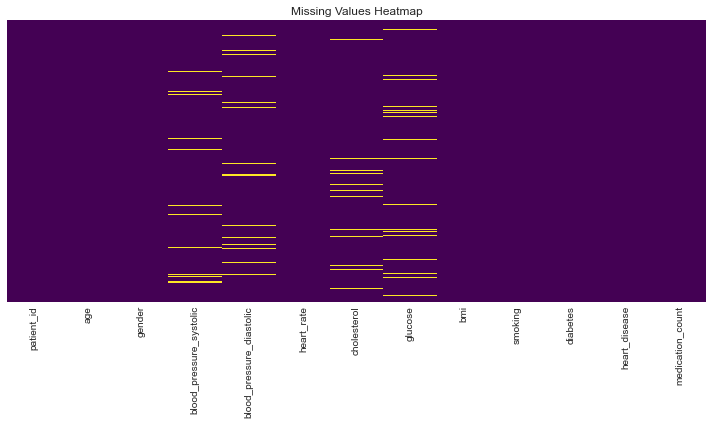

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(medical_df.isnull(), cbar=False, cmap='viridis', yticklabels= False)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

### Check the structure of the dataset

In [10]:
print("\n--- EXPLORATORY ANALYSIS ---")
print("\nDataset Shape:", medical_df.shape)


--- EXPLORATORY ANALYSIS ---

Dataset Shape: (1000, 13)


In [11]:
print("\nDataset Info:")
medical_df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                1000 non-null   int64  
 1   age                       1000 non-null   int64  
 2   gender                    1000 non-null   object 
 3   blood_pressure_systolic   938 non-null    float64
 4   blood_pressure_diastolic  946 non-null    float64
 5   heart_rate                1000 non-null   int64  
 6   cholesterol               952 non-null    float64
 7   glucose                   955 non-null    float64
 8   bmi                       1000 non-null   float64
 9   smoking                   1000 non-null   object 
 10  diabetes                  1000 non-null   int64  
 11  heart_disease             1000 non-null   int64  
 12  medication_count          1000 non-null   int64  
dtypes: float64(5), int64(6), object(2)
memory usage: 

In [12]:
print("\nSummary Statistics:")
medical_df.describe()


Summary Statistics:


,patient_id,age,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,cholesterol,glucose,bmi,diabetes,heart_disease,medication_count
count,1000.000000,1000.000000,938.000000,946.000000,1000.000000,952.000000,955.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,64.809000,128.866738,85.464059,74.489000,199.971639,98.541361,25.928055,0.152000,0.197000,1.982000
std,288.819436,15.327278,20.749056,15.077271,10.029879,39.755460,25.037605,4.961573,0.359201,0.397931,1.365848
min,1.000000,21.000000,63.000000,23.000000,43.000000,55.000000,14.000000,8.529406,0.000000,0.000000,0.000000
25%,250.750000,54.000000,115.000000,76.000000,67.000000,172.000000,82.000000,22.597465,0.000000,0.000000,1.000000
50%,500.500000,65.000000,129.000000,85.000000,75.000000,200.000000,99.000000,25.942392,0.000000,0.000000,2.000000
75%,750.250000,75.000000,143.000000,96.000000,81.000000,226.000000,115.000000,29.298489,0.000000,0.000000,3.000000
max,1000.000000,118.000000,198.000000,132.000000,106.000000,320.000000,166.000000,44.598425,1.000000,1.000000,8.000000


#### Missing value analysis

In [13]:
print("\n--- MISSING VALUE ANALYSIS ---")
missing_values = medical_df.isnull().sum()
missing_percentage = (missing_values / len(medical_df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})
missing_df[missing_df['Missing Values'] > 0]


--- MISSING VALUE ANALYSIS ---


,Missing Values,Percentage
blood_pressure_systolic,62,6.2
blood_pressure_diastolic,54,5.4
cholesterol,48,4.8
glucose,45,4.5


### Handling missing values

- we impute missing values with median for numerical columns

In [17]:
#medical_df['blood_pressure_systolic'].head()
# mean, median, mode

In [15]:
print("\n--- HANDLING MISSING VALUES ---")

for col in ['blood_pressure_systolic', 'blood_pressure_diastolic', 'cholesterol', 'glucose']:
    median_value = medical_df[col].median()
    medical_df[col].fillna(median_value, inplace=True)

print("Missing values after imputation:")
medical_df.isnull().sum()


--- HANDLING MISSING VALUES ---
Missing values after imputation:


patient_id                  0
age                         0
gender                      0
blood_pressure_systolic     0
blood_pressure_diastolic    0
heart_rate                  0
cholesterol                 0
glucose                     0
bmi                         0
smoking                     0
diabetes                    0
heart_disease               0
medication_count            0
dtype: int64

### Descriptive statistics by groups

In [ ]:
# map, filter, reduce

In [16]:

print("\n--- DESCRIPTIVE STATISTICS BY GROUPS ---")
print("\nDescriptive statistics by gender:")
gender_stats = medical_df.groupby('gender').agg({
    'age': ['mean', 'std', 'min', 'max'],
    'blood_pressure_systolic': ['mean', 'std', 'min', 'max'],
    'cholesterol': ['mean', 'std', 'min', 'max'],
    'heart_disease': 'mean'  # Proportion with heart disease
})
gender_stats


--- DESCRIPTIVE STATISTICS BY GROUPS ---

Descriptive statistics by gender:


age                     blood_pressure_systolic             \
             mean        std min  max                    mean        std   
gender                                                                     
Female  64.982955  15.547006  21  118              128.950758  21.212699   
Male    64.614407  15.091780  24  104              128.790254  18.787912   

                    cholesterol                         heart_disease  
         min    max        mean        std   min    max          mean  
gender                                                                 
Female  63.0  198.0  202.096591  39.920416  55.0  317.0      0.204545  
Male    79.0  194.0  197.597458  37.381363  86.0  320.0      0.188559

### Descriptive statistics by age groups

In [17]:

# Create age groups
bins = [0, 40, 60, 80, 100]
labels = ['<40', '40-60', '60-80', '>80']
medical_df['age_group'] = pd.cut(medical_df['age'], bins=bins, labels=labels) # cut function segements age into the bins


In [18]:
age_group_stats = medical_df.groupby('age_group').agg({
    'blood_pressure_systolic': ['mean', 'std'],
    'cholesterol': ['mean', 'std'],
    'heart_disease': 'mean',
    'diabetes': 'mean',
    'medication_count': 'mean'
})
age_group_stats

blood_pressure_systolic            cholesterol             \
                             mean        std        mean        std   
age_group                                                             
<40                    130.728814  20.341761  206.610169  35.172000   
40-60                  129.810976  20.137925  198.411585  38.977428   
60-80                  128.402222  19.631357  199.286667  38.763920   
>80                    127.393333  21.486970  202.120000  39.988072   

          heart_disease  diabetes medication_count  
                   mean      mean             mean  
age_group                                           
<40            0.118644  0.186441         1.898305  
40-60          0.158537  0.167683         2.073171  
60-80          0.197778  0.148889         1.948889  
>80            0.306667  0.100000         1.933333

In [19]:
# Correlation analysis
print("\n--- CORRELATION ANALYSIS ---")
# Select numerical columns for correlation
numerical_cols = ['age', 'blood_pressure_systolic', 'blood_pressure_diastolic', 
                 'heart_rate', 'cholesterol', 'glucose', 'bmi', 'diabetes', 
                 'heart_disease', 'medication_count']
corr_matrix = medical_df[numerical_cols].corr()
print("Correlation Matrix:")
corr_matrix.round(2)


--- CORRELATION ANALYSIS ---
Correlation Matrix:


,age,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,cholesterol,glucose,bmi,diabetes,heart_disease,medication_count
age,1.00,-0.02,-0.02,0.10,0.01,0.02,0.04,-0.05,0.14,-0.02
blood_pressure_systolic,-0.02,1.00,-0.03,0.02,0.01,-0.02,-0.01,-0.04,0.01,-0.03
blood_pressure_diastolic,-0.02,-0.03,1.00,-0.02,0.08,0.04,0.01,-0.02,0.02,0.01
heart_rate,0.10,0.02,-0.02,1.00,-0.00,0.02,0.00,0.01,-0.05,-0.02
cholesterol,0.01,0.01,0.08,-0.00,1.00,-0.02,-0.04,0.07,0.17,-0.02
glucose,0.02,-0.02,0.04,0.02,-0.02,1.00,-0.01,-0.02,0.00,0.01
bmi,0.04,-0.01,0.01,0.00,-0.04,-0.01,1.00,-0.04,-0.00,-0.03
diabetes,-0.05,-0.04,-0.02,0.01,0.07,-0.02,-0.04,1.00,0.00,0.06
heart_disease,0.14,0.01,0.02,-0.05,0.17,0.00,-0.00,0.00,1.00,-0.04
medication_count,-0.02,-0.03,0.01,-0.02,-0.02,0.01,-0.03,0.06,-0.04,1.00


### Feature engineering and derived metrics

In [20]:
m = medical_df['blood_pressure_systolic'] >= 140
t = medical_df['blood_pressure_diastolic'] >= 90 #.astype(int))
(m | t).astype(int)


0      0
1      0
2      0
3      1
4      1
      ..
995    0
996    1
997    1
998    0
999    1
Length: 1000, dtype: int64

In [21]:

print("\n--- FEATURE ENGINEERING ---")
# Create new features
medical_df['hypertension'] = ((medical_df['blood_pressure_systolic'] >= 140) | 
                              (medical_df['blood_pressure_diastolic'] >= 90)).astype(int)
medical_df['pulse_pressure'] = medical_df['blood_pressure_systolic'] - medical_df['blood_pressure_diastolic']
medical_df['has_risk_factor'] = ((medical_df['hypertension'] == 1) | 
                                (medical_df['cholesterol'] > 240) | 
                                (medical_df['diabetes'] == 1) | 
                                (medical_df['smoking'] == 'Current')).astype(int)

print("New features:")
medical_df[['hypertension', 'pulse_pressure', 'has_risk_factor']].head()



--- FEATURE ENGINEERING ---
New features:


,hypertension,pulse_pressure,has_risk_factor
0,0,49.0,0
1,0,41.0,1
2,0,60.0,0
3,1,103.0,1
4,1,82.0,1


In [28]:
print("\nRisk factor distribution:")
medical_df['has_risk_factor'].value_counts(normalize=True) * 100 
# normalize=True means return relative frequencies of the unique values


Risk factor distribution:


has_risk_factor
1    73.2
0    26.8
Name: proportion, dtype: float64

#### Pivot table: Mean cholesterol by age group and gender

In [29]:
# Pivot tables for complex aggregations
print("\n--- PIVOT TABLES ---")

pivot_table = pd.pivot_table(
    medical_df, 
    values='cholesterol',
    index='age_group',
    columns='gender',
    aggfunc='mean'
)
print("Mean cholesterol by age group and gender:")
pivot_table


--- PIVOT TABLES ---
Mean cholesterol by age group and gender:


gender,Female,Male
age_group,,
<40,203.133333,210.206897
40-60,202.610465,193.782051
60-80,201.045643,197.258373
>80,203.293333,200.946667


### Pivot table: Disease prevalence by age group and smoking status

In [30]:

disease_pivot = pd.pivot_table(
    medical_df,
    values=['heart_disease', 'diabetes'],
    index='age_group',
    columns='smoking',
    aggfunc='mean'
)
print("\nDisease prevalence by age group and smoking status:")
print(disease_pivot.round(2))


Disease prevalence by age group and smoking status:
          diabetes              heart_disease             
smoking    Current Former Never       Current Former Never
age_group                                                 
<40           0.11   0.20  0.20          0.00   0.15  0.13
40-60         0.14   0.17  0.18          0.17   0.15  0.16
60-80         0.18   0.16  0.13          0.25   0.22  0.17
>80           0.11   0.11  0.09          0.31   0.36  0.28


In [31]:
# Percentile-based analysis
print("\n--- PERCENTILE ANALYSIS ---")
percentiles = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
percentile_stats = medical_df[['age', 'blood_pressure_systolic', 'cholesterol', 'glucose']].quantile(percentiles)
print("Key Percentiles:")
print(percentile_stats)


--- PERCENTILE ANALYSIS ---
Key Percentiles:
        age  blood_pressure_systolic  cholesterol  glucose
0.10   44.9                   102.00       151.00    66.90
0.25   54.0                   116.00       174.00    83.00
0.50   65.0                   129.00       200.00    99.00
0.75   75.0                   141.00       224.00   114.00
0.90   84.0                   153.10       250.00   130.00
0.95   92.0                   160.00       267.00   138.00
0.99  103.0                   180.02       289.05   153.01


In [32]:
# Calculate IQR and identify outliers
Q1 = medical_df['cholesterol'].quantile(0.25)
Q3 = medical_df['cholesterol'].quantile(0.75)
IQR = Q3 - Q1
print(f"\nCholesterol IQR: {IQR:.2f}")
outlier_count = ((medical_df['cholesterol'] < (Q1 - 1.5 * IQR)) | 
                 (medical_df['cholesterol'] > (Q3 + 1.5 * IQR))).sum()
print(f"Number of cholesterol outliers: {outlier_count}")


Cholesterol IQR: 50.00
Number of cholesterol outliers: 11


In [33]:
# Stratified statistics
print("\n--- STRATIFIED STATISTICS ---")
# Define a high-risk group
medical_df['high_risk'] = ((medical_df['age'] > 65) & 
                          (medical_df['cholesterol'] > 240) & 
                          (medical_df['hypertension'] == 1)).astype(int)

# Compare disease prevalence in high-risk vs. general population
risk_stats = medical_df.groupby('high_risk').agg({
    'heart_disease': 'mean',
    'diabetes': 'mean'}) * 100
print("Disease prevalence by risk group (%):")
risk_stats


--- STRATIFIED STATISTICS ---
Disease prevalence by risk group (%):


,heart_disease,diabetes
high_risk,,
0,18.723849,14.748954
1,40.909091,25.000000


In [34]:
# Categorical data analysis
print("\n--- CATEGORICAL DATA ANALYSIS ---")
# Frequency tables
smoking_freq = medical_df['smoking'].value_counts(normalize=True) * 100
print("Smoking status distribution (%):")
smoking_freq


--- CATEGORICAL DATA ANALYSIS ---
Smoking status distribution (%):


smoking
Never      51.6
Former     28.7
Current    19.7
Name: proportion, dtype: float64

In [35]:
# Summary statistics for a clinical report
print("\n--- CLINICAL REPORT SUMMARY ---")
clinical_summary = pd.DataFrame({
    'Metric': [
        'Total Patients',
        'Age (Mean ± SD)',
        'Male/Female Ratio',
        'Hypertension Prevalence (%)',
        'Diabetes Prevalence (%)',
        'Heart Disease Prevalence (%)',
        'Current Smokers (%)',
        'Average Medications',
        'Average BMI',
        'High Cholesterol (>240) (%)'
    ],
    'Value': [
        len(medical_df),
        f"{medical_df['age'].mean():.2f} ± {medical_df['age'].std():.2f}",
        f"{(medical_df['gender'] == 'Male').sum()/(medical_df['gender'] == 'Female').sum():.2f}",
        f"{medical_df['hypertension'].mean() * 100:.1f}%",
        f"{medical_df['diabetes'].mean() * 100:.1f}%",
        f"{medical_df['heart_disease'].mean() * 100:.1f}%",
        f"{(medical_df['smoking'] == 'Current').mean() * 100:.1f}%",
        f"{medical_df['medication_count'].mean():.1f}",
        f"{medical_df['bmi'].mean():.1f}",
        f"{(medical_df['cholesterol'] > 240).mean() * 100:.1f}%"
    ]
})
print(clinical_summary)


--- CLINICAL REPORT SUMMARY ---
                         Metric          Value
0                Total Patients           1000
1               Age (Mean ± SD)  64.81 ± 15.33
2             Male/Female Ratio           0.89
3   Hypertension Prevalence (%)          54.4%
4       Diabetes Prevalence (%)          15.2%
5  Heart Disease Prevalence (%)          19.7%
6           Current Smokers (%)          19.7%
7           Average Medications            2.0
8                   Average BMI           25.9
9   High Cholesterol (>240) (%)          15.1%
